# Lab 20: Training a decision tree ensemble to diagnose heart disease

Context
* Cardiovascular disease (CVDs) is the number one cause of death globally, taking an estimated 17.9 million lives each year, which accounts for 31% of all deaths worldwide. Four out of five CVD deaths are due to heart attacks and strokes, and one-third of these deaths occur prematurely in people under 70 years of age. Heart failure is a common event caused by CVDs.
* People with cardiovascular disease or who are at high cardiovascular risk (due to the presence of one or more risk factors such as hypertension, diabetes, hyperlipidaemia or already established disease) need early detection and management.

In [7]:
import numpy as np
import pandas as pd

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

from xgboost import XGBClassifier

import matplotlib.pyplot as plt
plt.style.use('./deeplearning.mplstyle')

RANDOM_STATE = 55 ## We will pass it to every sklearn call so we ensure reproducibility

## Overview of using XGBoost

In [8]:
# Using XGBoost for decision tree ensembles
# from xgboost import XGBClassifier

# model = XGBClassifier()  # if building classification trees (outputs have discreet values)
# model = XGBRegresor()    # if building regression trees (outputs are on a continuum) 

# model.fit(X_train, y_train)
# y_pred = model.predict(X_test

## Prepare Data

### Load Dataset (11 features that can be used to predict heart disease)

source: [Kaggle's Heart Failure Prediction Dataset](https://www.kaggle.com/datasets/fedesoriano/heart-failure-prediction) 
 
Attribute Information
* Age: age of the patient [years]
* Sex: sex of the patient [M: Male, F: Female]
* ChestPainType: chest pain type [TA: Typical Angina, ATA: Atypical Angina, NAP: Non-Anginal Pain, ASY: Asymptomatic]
* RestingBP: resting blood pressure [mm Hg]
* Cholesterol: serum cholesterol [mm/dl]
* FastingBS: fasting blood sugar [1: if FastingBS > 120 mg/dl, 0: otherwise]
* RestingECG: resting electrocardiogram results [Normal: Normal, ST: having ST-T wave abnormality (T wave inversions and/or ST elevation or depression of > 0.05 mV), LVH: showing probable or definite left ventricular hypertrophy by Estes' criteria]
* MaxHR: maximum heart rate achieved [Numeric value between 60 and 202]
* ExerciseAngina: exercise-induced angina [Y: Yes, N: No]
* Oldpeak: oldpeak = ST [Numeric value measured in depression]
* ST_Slope: the slope of the peak exercise ST segment [Up: upsloping, Flat: flat, Down: downsloping]
* HeartDisease: output class [1: heart disease, 0: Normal]

In [26]:
# Load the dataset using pandas
original_df = pd.read_csv("data/heart.csv")

# print out original dataframe
original_df.head()

# print original number of features; NB: This includes the labelled output column because we have not yet isolated x_train from y_train.
print(len(original_df.columns))

12


### Use one-hot encoding to transform categorical features into binary features

Pandas has a built-in method to one-hot encode variables: `pd.get_dummies` 

Optional arguments that we will use:
* data: DataFrame to be used
* prefix: A list with prefixes, so we know which value we are dealing with
* columns: the list of columns that will be one-hot encoded.
* prefix and columns must have the same length.

In [27]:
# Create a list of names for the categorical columns that need to be transformed.
cat_variables = [
    'Sex',
    'ChestPainType',
    'RestingECG',
    'ExerciseAngina',
    'ST_Slope'
]

# Replace the non-binary columns with the one-hot encoded (binary) columns. 
# It looks like this creates new column names as prefix + _ + category.
all_binary_df = pd.get_dummies(data = df, prefix = cat_variables, columns = cat_variables)

# print out updated (all binary) dataframe
all_binary_df.head()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_F,Sex_M,ChestPainType_ASY,...,ChestPainType_NAP,ChestPainType_TA,RestingECG_LVH,RestingECG_Normal,RestingECG_ST,ExerciseAngina_N,ExerciseAngina_Y,ST_Slope_Down,ST_Slope_Flat,ST_Slope_Up
0,40,140,289,0,172,0.0,0,False,True,False,...,False,False,False,True,False,True,False,False,False,True
1,49,160,180,0,156,1.0,1,True,False,False,...,True,False,False,True,False,True,False,False,True,False
2,37,130,283,0,98,0.0,0,False,True,False,...,False,False,False,False,True,True,False,False,False,True
3,48,138,214,0,108,1.5,1,True,False,True,...,False,False,False,True,False,False,True,False,True,False
4,54,150,195,0,122,0.0,0,False,True,False,...,True,False,False,True,False,True,False,False,False,True


In [28]:
# Show the updated number of columns (increased from 12 to 21)
print(len(all_binary_df.columns))

21


In [29]:
# Isolate the input features (by removing the labelled output column)
features = [x for x in all_binary_df.columns if x not in 'HeartDisease'] 
print(len(features))

20


### Split the data into training and testing sets

In [30]:
# We will use the function train_test_split from Scikit-learn to split the data.
# Use help to check the arguments.
help(train_test_split)

Help on function train_test_split in module sklearn.model_selection._split:

train_test_split(*arrays, test_size=None, train_size=None, random_state=None, shuffle=True, stratify=None)
    Split arrays or matrices into random train and test subsets.

    Quick utility that wraps input validation,
    ``next(ShuffleSplit().split(X, y))``, and application to input data
    into a single call for splitting (and optionally subsampling) data into a
    one-liner.

    Read more in the :ref:`User Guide <cross_validation>`.

    Parameters
    ----------
    *arrays : sequence of indexables with same length / shape[0]
        Allowed inputs are lists, numpy arrays, scipy-sparse
        matrices or pandas dataframes.

    test_size : float or int, default=None
        If float, should be between 0.0 and 1.0 and represent the proportion
        of the dataset to include in the test split. If int, represents the
        absolute number of test samples. If None, the value is set to the
        com

In [32]:
# Keep the shuffle = True since our dataset has not any time dependency.
X_train, X_val, y_train, y_val = train_test_split(all_binary_df[features], all_binary_df['HeartDisease'], train_size = 0.8, random_state = RANDOM_STATE)

print(f'train samples: {len(X_train)}')
print(f'validation samples: {len(X_val)}')
print(f'target proportion: {sum(y_train)/len(y_train):.4f}')

train samples: 734
validation samples: 184
target proportion: 0.5518


In [36]:
# inspect training examples
print(X_train.shape)
print(type(X_train))
print(X_train.iloc[0])

(734, 20)
<class 'pandas.core.frame.DataFrame'>
Age                     57
RestingBP               95
Cholesterol              0
FastingBS                1
MaxHR                  182
Oldpeak                0.7
Sex_F                False
Sex_M                 True
ChestPainType_ASY     True
ChestPainType_ATA    False
ChestPainType_NAP    False
ChestPainType_TA     False
RestingECG_LVH       False
RestingECG_Normal     True
RestingECG_ST        False
ExerciseAngina_N      True
ExerciseAngina_Y     False
ST_Slope_Down         True
ST_Slope_Flat        False
ST_Slope_Up          False
Name: 309, dtype: object


## Build a single the decision tree (using Scikit-learn)


There are several hyperparameters in the Decision Tree object (from Scikit-learn) that are used in this lab:
* min_samples_split: the minimum number of samples required to split an internal node; Choosing a higher min_samples_split can reduce the number of splits and may help to reduce overfitting.
* max_depth: maximum depth of the tree; Choosing a lower max_depth can reduce the number of splits and may help to reduce overfitting.
  
This lab does not perform feature selection nor hyperparameter tuning, but both are available in Scikit-learn. 

### Build multiple trees to identify the optimal number of samples that should be required to split an decision node

In [68]:
# Setup multiple sets parameters for the decision tree object (so we can create multiple trees).
# min_samples_split is the minimum number of samples required to split an internal node
# If integer: the actual quantity of samples. If float: the percentage of the dataset.
min_samples_split_list = [2,10, 30, 50, 100, 200, 300, 700] 

In [58]:
# Use for-loop to create multiple trees and populate the holding arrays.
# Within the same loop, make predictionss on the training set and the test set.

accuracy_list_train_splits = []
accuracy_list_val_splits = []
for min_samples_split in min_samples_split_list:
    
    # Define and fit the model (chained methods)
    # You can fit the model at the same time you define it, because the fit function returns the fitted estimator.
    model = DecisionTreeClassifier(min_samples_split = min_samples_split,
                                   random_state = RANDOM_STATE).fit(X_train,y_train) 

    # record predictions on the training dataset
    predictions_train = model.predict(X_train) 
    accuracy_train = accuracy_score(predictions_train,y_train)
    accuracy_list_train_splits.append(accuracy_train)

    # record predictions on the test dataset
    predictions_val = model.predict(X_val) 
    accuracy_val = accuracy_score(predictions_val,y_val)
    accuracy_list_val_splits.append(accuracy_val)

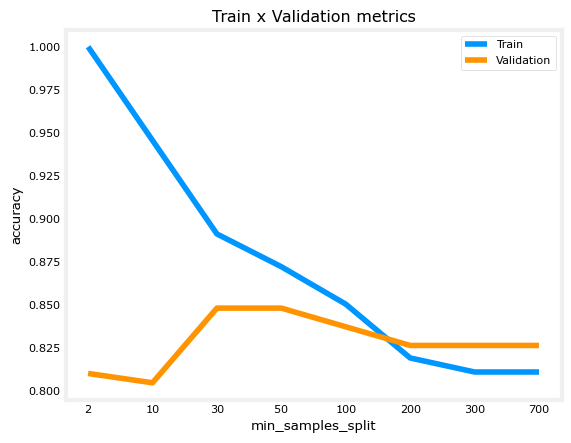

In [59]:
# Plot the results
plt.title('Train x Validation metrics')
plt.xlabel('min_samples_split')
plt.ylabel('accuracy')
plt.xticks(ticks = range(len(min_samples_split_list )),labels=min_samples_split_list)
plt.plot(accuracy_list_train_splits)
plt.plot(accuracy_list_val_splits)
plt.legend(['Train','Validation'])

# Conclusions: 
#   When min_samples_split is very low, the plot is over-fitted (works well on training set but not on test set).
#   Increasing min_samples_split reduces the over-fitting... test set starts to perform better. 

# The best value for min_samples_split is:
# min_samples_split = 50

### Build multiple trees to identify the optimal maximum depth of the tree

In [50]:
# Setup multiple sets parameters for the decision tree object (so we can create multiple trees).
max_depth_list = [1,2, 3, 4, 8, 16, 32, 64, None] # None means that there is no depth limit.

In [60]:
# Use for-loop to create multiple trees and populate the holding arrays.
# Within the same loop, make predictionss on the training set and the test set.

accuracy_list_train_depth = []
accuracy_list_val_depth = []
for max_depth in max_depth_list:
    
    # Define and fit the model (chained methods)
    # You can fit the model at the same time you define it, because the fit function returns the fitted estimator.
    model = DecisionTreeClassifier(max_depth = max_depth,
                                   random_state = RANDOM_STATE).fit(X_train,y_train) 

    # record predictions on the training dataset
    predictions_train = model.predict(X_train)
    accuracy_train = accuracy_score(predictions_train,y_train)
    accuracy_list_train_depth.append(accuracy_train)

    # record predictions on the test dataset
    predictions_val = model.predict(X_val) 
    accuracy_val = accuracy_score(predictions_val,y_val)
    accuracy_list_val_depth.append(accuracy_val)

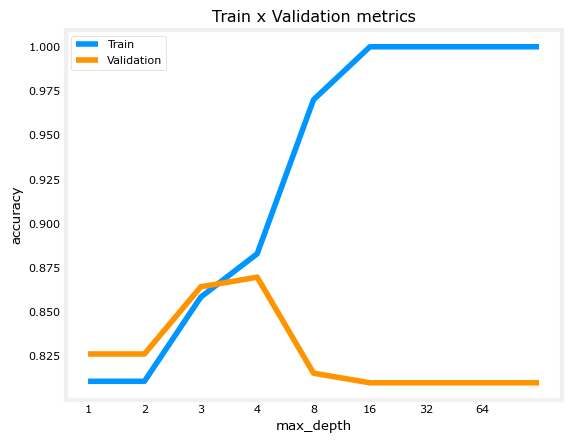

In [61]:
# Plot the results
plt.title('Train x Validation metrics')
plt.xlabel('max_depth')
plt.ylabel('accuracy')
plt.xticks(ticks = range(len(max_depth_list )),labels=max_depth_list)
plt.plot(accuracy_list_train_depth)
plt.plot(accuracy_list_val_depth)
plt.legend(['Train','Validation'])

# Conclusions: 

# In general, reducing max_depth reduces overfitting.
#    Reducing max_depth from 8 to 4 increases validation accuracy closer to training accuracy, while significantly reducing training accuracy.
#    The validation accuracy reaches the highest at tree_depth=4.
#    When the max_depth is smaller than 3, both training and validation accuracy decreases. The tree cannot make enough splits to distinguish positives from negatives (the model is underfitting the training set).
#    When the max_depth is too high ( >= 5), validation accuracy decreases while training accuracy increases, indicating that the model is overfitting to the training set.

# The best value for max_depth is:
# max_depth = 4

### Use optimal minimum split and max tree depth (derived above) to build a decision tree

In the above two sections, we visually confirmed optimal values for the below. Now we will plug those values into a single decision tree.
* min_samples_split = 50
* max_depth = 4

In [64]:
decision_tree_model = DecisionTreeClassifier(min_samples_split = 50,
                                             max_depth = 4,
                                             random_state = RANDOM_STATE).fit(X_train,y_train)

In [66]:
print(f"Metrics train:\n\tAccuracy score: {accuracy_score(decision_tree_model.predict(X_train),y_train):.4f}")
print(f"Metrics validation:\n\tAccuracy score: {accuracy_score(decision_tree_model.predict(X_val),y_val):.4f}")

# Conclusion: No sign of over-fitting (training and test groups have roughly the same score) but the accuracy is not great (roughly 86%)

Metrics train:
	Accuracy score: 0.8665
Metrics validation:
	Accuracy score: 0.8696


## Build random forest (a tree ensemble)

We wil use Scikit-learn again and set the following parameters: 
* `min_samples_split`: the minimum number of samples required to split an internal node; If integer: the actual quantity of samples. If float: the percentage of the dataset.; Choosing a higher min_samples_split can reduce the number of splits and may help to reduce overfitting.
* `max_depth`: maximum depth of the tree; Choosing a lower max_depth can reduce the number of splits and may help to reduce overfitting.
* `n_estimators`: the number of decision trees to include in the random forest; The default is 100. We will choose  between 10, 50, 100, and 500.
* `max_features`: the number of features that can be randomly selected for each tree; We will use the default: square root of the total number of features.
* `n_jobs`: the number of CPU cores to use in parallel; Each tree is independant of the others so you can parallelize the work. Changing this parameter doesn't impact the performance but it can reduce the training time.
  

In [69]:
# Setup multiple sets parameters for the forest
min_samples_split_list = [2,10, 30, 50, 100, 200, 300, 700]  
max_depth_list = [2, 4, 8, 16, 32, 64, None]
n_estimators_list = [10,50,100,500]

### Build multiple forests to identify the optimal number of samples that should be required to split an decision node

### Build multiple forests to identify the optimal maximum depth of the tree

### Build multiple forests to identify the optimal number of trees in a forest